In [26]:
import os
from typing import TypedDict, List, Dict

from openai import OpenAI
from langsmith.wrappers import wrap_openai
from langsmith import traceable

from langgraph.graph import StateGraph, START, END

from legal_multi_agent.rag.pipeline import legal_rag_retrieve, format_results_for_llm
from legal_multi_agent.utils.toon import extract_toon_answer, extract_toon_critic

In [27]:
OPENROUTER_API_KEY = os.environ["OPENROUTER_API_KEY"]
MODEL_ID = "qwen/qwen3-235b-a22b-2507"

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
)
client = wrap_openai(client)

In [28]:
import pandas as pd
import json


DATA_PATH = r"F:\Thesis\project\403-vekalat\structured_questions.csv"

df = pd.read_csv(DATA_PATH)
row = df[df["question_number"] == 82].iloc[0]

question_number = int(row["question_number"])
category = str(row["category"]).strip()
question = str(row["question"]).strip()
opts_raw = row["options"]

def to_list(opts):
    if isinstance(opts, list): 
        return opts
    if isinstance(opts, str):
        try:
            v = json.loads(opts)
            if isinstance(v, list): 
                return v
        except Exception:
            pass
        for sep in ["|","؛",";","/","\\","،","\n"]:
            if sep in opts:
                return [x.strip() for x in opts.split(sep) if x.strip()]
        return [opts.strip()]
    return [str(opts)]

import re

def render_numeric_options(opts):
    clean = []
    for o in opts:
        m = re.match(r"^\s*\d+\)\s*(.+)$", o)
        if m:
            o = m.group(1).strip()
        clean.append(o)
    return "\n".join(f"{i+1}) {o}" for i, o in enumerate(clean))


options_list = to_list(opts_raw)
options_text = render_numeric_options(options_list)

print("Q#", question_number, category)
print(question)
print(options_text)

Q# 82 حقوق جزا
سربازی در جبهه جنگ در حالی که در محاصره دشمن ،است برای اینکه بیسیم در اختیار وی و اطلاعات محرمانه درون آن به دست دشمن نیفتد بیسیم را تخریب میکند سرباز از چه دفاعی در مقابل جرم تخریب اموال نظامی در حقوق ایران میتواند استفاده کند؟
1) امر آمر قانونی
2) اجبار
3) اجرای قانون اهم
4) دفاع مشروع


In [29]:
class MAState(TypedDict, total=False):
    question_number: int
    category: str
    domain: str

    question: str
    options_text: str

    context: str
    rag_results: List[Dict]

    draft_raw: str
    draft_toon: Dict

    critic_raw: str
    critic_toon: Dict

    final_raw: str
    final_toon: Dict

    revision_count: int
    max_revisions: int
    next: str

    context_preview: str
    docs_meta: List[Dict]


In [30]:
@traceable(name="supervisor_node")
def supervisor_node(state: MAState) -> MAState:
    # 1) هنوز کانتکست نداریم → برو سراغ Researcher
    if not state.get("context"):
        return {"next": "researcher"}

    # 2) هنوز جوابی تولید نشده → Reasoner
    if not state.get("draft_toon"):
        return {"next": "reasoner"}

    # 3) اگر final_toon از قبل داریم → FINISH (کار تمام شده)
    if state.get("final_toon"):
        return {"next": "FINISH"}

    # 4) اگر هنوز critic اجرا نشده → برو critic
    if not state.get("critic_toon"):
        return {"next": "critic"}

    # 5) بر اساس نظر Critic تصمیم بگیر
    needs = bool(state["critic_toon"]["needs_revision"])
    rc = int(state.get("revision_count", 0))
    mr = int(state.get("max_revisions", 2))

    # اگر نیاز به اصلاح هست و هنوز به سقف نرسیده‌ایم → یک بار دیگر Reasoner
    if needs and rc < mr:
        return {"next": "reasoner"}

    # در غیر این صورت → finalize (یک‌بار) و بعد از آن FINISH
    return {"next": "finalize"}


In [31]:
def domain_top_k(domain: str) -> int:
    if domain in ("criminal", "criminal_procedure"):
        return 6
    if domain == "constitutional":
        return 6
    return 5

@traceable(name="researcher_node")
def researcher_node(state: MAState) -> MAState:
    q = state["question"]
    domain = state.get("domain", "")
    top_k = domain_top_k(domain)

    results = legal_rag_retrieve(
        query=q, method="auto", top_k=top_k, use_rerank=True, verbose=True
    )
    context = format_results_for_llm(results, include_metadata=True)

    # یک preview کوتاه برای چاپ/دیباگ (برای اینکه خروجی خیلی بزرگ نشود)
    preview = context[:2500]

    # همچنین یک لیست meta سبک‌تر برای دیدن اینکه دقیقاً چه اسنادی آمده
    docs_meta = []
    for i, r in enumerate(results[:10], start=1):
        m = r.get("metadata", {}) if isinstance(r, dict) else {}
        docs_meta.append({
            "i": i,
            "law": m.get("law"),
            "article_number": m.get("article_number"),
            "source_type": m.get("source_type"),
            "title": m.get("title"),
        })

    return {
        "rag_results": results,
        "context": context,
        "context_preview": preview,
        "docs_meta": docs_meta,
    }


In [32]:
@traceable(name="reasoner_node")
def reasoner_node(state: MAState) -> MAState:
    q = state["question"]
    options = state["options_text"]
    ctx = state.get("context", "")

    critic = state.get("critic_toon")
    critic_hint = ""
    must_revise = False
    if critic:
        needs = critic.get("needs_revision", False)
        if needs:
            must_revise = True
            critic_hint = f"Issue: {critic.get('issue','')}\nAction: {critic.get('action','')}\n"

    system_msg = (
        "You are an Iranian legal exam QA assistant.\n"
        "Rules:\n"
        "1) Use ONLY the provided SOURCES.\n"
        "2) Answer in Persian.\n"
        "3) Choose exactly one option number (1-4).\n"
        "4) Provide a short legal explanation (1-2 Persian sentences).\n"
        "5) Output MUST be exactly one TOON table with one row.\n\n"
        "Output format (exact):\n"
        "results{explanation,answer,confidence}:\n"
        "<explanation>,<1-4>,<1-5>\n"
        "Do not output anything else."
    )

    user_msg = f"""SOURCES:
{ctx}

QUESTION (Persian):
{q}

OPTIONS:
{options}

CRITIC FEEDBACK (if any):
{critic_hint}

INSTRUCTIONS:
- If there is no CRITIC FEEDBACK, answer normally.
- If CRITIC FEEDBACK exists and needs_revision=true, you MUST correct the explanation
  according to the critic's issue/action. The new explanation MUST be different from
  the previous one and MUST fix the reported problem.
"""

    resp = client.chat.completions.create(
        model=MODEL_ID,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg},
        ],
        temperature=0.2,
    )

    draft_raw = resp.choices[0].message.content
    draft_toon = extract_toon_answer(draft_raw)

    rc = int(state.get("revision_count", 0))
    if state.get("draft_toon") or critic:
        rc += 1

    return {"draft_raw": draft_raw, "draft_toon": draft_toon, "revision_count": rc}


In [33]:
@traceable(name="critic_node")
def critic_node(state: MAState) -> MAState:
    q = state["question"]
    options = state["options_text"]
    ctx = state.get("context", "")
    draft_raw = state.get("draft_raw", "")

    system_msg = (
        "Role: exam QA critic for Iranian law.\n"
        "You see SOURCES (legal texts + cases), the question, options, and the assistant's TOON answer.\n"
        "Your job is to check for CLEAR ERRORS, not to reject every unstated doctrinal detail.\n"
        "You MUST treat the assistant's legal doctrine as acceptable UNLESS it directly contradicts the SOURCES.\n"
        "Only set needs_revision=true if:\n"
        "- The chosen option clearly conflicts with the SOURCES, OR\n"
        "- The explanation clearly contradicts or misquotes the SOURCES, OR\n"
        "- The TOON format is invalid.\n"
        "If the explanation adds reasonable doctrinal concepts (e.g., distinguishing 'condition of act' vs 'condition of result')"
        " that do not conflict with SOURCES, you MUST NOT mark them as unsupported.\n"
        "Return ONLY a TOON table:\n"
        "results{needs_revision,issue,action}:\n"
        "<true/false>,<short issue>,<short action>\n"
        "Constraints:\n"
        "- issue: one short English phrase (no comma).\n"
        "- action: one short English phrase (no comma), max 10 words.\n"
        "Do not output anything else."
    )


    user_msg = f"""SOURCES:
{ctx}

QUESTION:
{q}

OPTIONS:
{options}

ASSISTANT OUTPUT:
{draft_raw}

Check:\n- Valid TOON format (one row)\n- answer is 1-4\n- explanation is grounded in SOURCES
"""

    resp = client.chat.completions.create(
        model=MODEL_ID,
        messages=[{"role": "system", "content": system_msg},
                  {"role": "user", "content": user_msg}],
        temperature=0.0,
    )

    critic_raw = resp.choices[0].message.content
    critic_toon = extract_toon_critic(critic_raw)

    # اگر critic_toon None شد یعنی خروجی critic خراب است؛ اینجا fail-safe:
    if critic_toon is None:
        critic_toon = {
            "needs_revision": True,
            "issue": "Critic output could not be parsed as TOON.",
            "action": "Return a valid TOON-CRITIC table exactly as specified.",
        }

    return {"critic_raw": critic_raw, "critic_toon": critic_toon}

In [34]:
@traceable(name="finalize_node")
def finalize_node(state):
    final_raw = state.get("draft_raw","")
    return {"final_raw": final_raw, "final_toon": extract_toon_answer(final_raw)}

In [35]:
workflow = StateGraph(MAState)

workflow.add_node("supervisor", supervisor_node)
workflow.add_node("researcher", researcher_node)
workflow.add_node("reasoner", reasoner_node)
workflow.add_node("critic", critic_node)
workflow.add_node("finalize", finalize_node)

workflow.add_edge(START, "supervisor")
workflow.add_edge("researcher", "supervisor")
workflow.add_edge("reasoner", "supervisor")
workflow.add_edge("critic", "supervisor")
workflow.add_edge("finalize", "supervisor")

workflow.add_conditional_edges(
    "supervisor",
    lambda s: s["next"],
    {
        "researcher": "researcher",
        "reasoner": "reasoner",
        "critic": "critic",
        "finalize": "finalize",
        "FINISH": END,
    },
)

graph = workflow.compile()

In [36]:
CATEGORY_TO_DOMAIN = {
    "حقوق مدنی": "civil",
    "آیین دادرسی مدنی": "civil_procedure",
    "حقوق تجارت": "commercial",
    "حقوق جزا": "criminal",
    "آیین دادرسی کیفری": "criminal_procedure",
    "حقوق اساسی": "constitutional",
}

domain = CATEGORY_TO_DOMAIN.get(category, "unknown")

inputs = {
    "question_number": question_number,
    "category": category,
    "domain": domain,
    "question": question,
    "options_text": options_text,
    "max_revisions": 2,
    "revision_count": 0,
}

out = graph.invoke(inputs)


def print_debug_bundle(state: dict):
    print("\n========== RESEARCHER → DOCS_META (top) ==========")
    docs_meta = state.get("docs_meta", [])
    if not docs_meta:
        print("(no docs_meta in state)")
    else:
        for d in docs_meta:
            print(d)

    print("\n========== RESEARCHER → CONTEXT_PREVIEW ==========")
    ctx_prev = state.get("context_preview", "")
    if not ctx_prev:
        print("(no context_preview in state)")
    else:
        print(ctx_prev)

    print("\n========== REASONER → DRAFT_RAW (TOON) ==========")
    draft_raw = state.get("draft_raw", "")
    if not draft_raw:
        print("(no draft_raw in state)")
    else:
        print(draft_raw)

    print("\n========== CRITIC → CRITIC_RAW (TOON) ==========")
    critic_raw = state.get("critic_raw", "")
    if not critic_raw:
        print("(no critic_raw in state)")
    else:
        print(critic_raw)


print_debug_bundle(out)

print("\n========== SUMMARY FIELDS ==========")
print("REVISION_COUNT:", out.get("revision_count"))
print("\nDRAFT_TOON:", out.get("draft_toon", None))
print("\nCRITIC_TOON:", out.get("critic_toon", None))
print("\nFINAL_RAW:\n", out.get("final_raw", ""))
print("\nFINAL_TOON:\n", out.get("final_toon", None))

📝 Query: سربازی در جبهه جنگ در حالی که در محاصره دشمن ،است برای اینکه بیسیم در اختیار وی ...
🎯 روش انتخاب شده: Metadata-aware
🎯 Metadata: law='قانون حداکثر استفاده از توان تولیدی و خدماتی کشور و حمایت از کالای ایرانی' | None None
🔍 فیلتر فقط قانون...
   ✓ 10 سند (law_only)
🔍 Semantic fallback...
✅ نهایی: 24 نتیجه
   ✓ Retrieved: 24 documents
🔄 Reranking 24 سند (بدون law+article)...
   ✓ Reranked: top 6 documents

========== RESEARCHER → DOCS_META (top) ==========
{'i': 1, 'law': None, 'article_number': 618, 'source_type': None, 'title': None}
{'i': 2, 'law': None, 'article_number': 591, 'source_type': None, 'title': None}
{'i': 3, 'law': None, 'article_number': None, 'source_type': None, 'title': 'تخریب به منظور ارتکاب سرقت'}
{'i': 4, 'law': None, 'article_number': None, 'source_type': None, 'title': 'عنصر مادی بزه تخریب'}
{'i': 5, 'law': None, 'article_number': None, 'source_type': None, 'title': 'تعیین عنوان مجرمانه'}
{'i': 6, 'law': None, 'article_number': 687, 'source_type': None, 

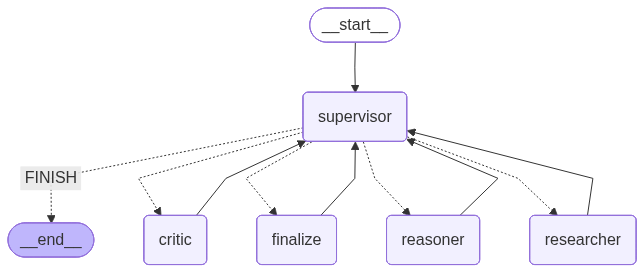

In [37]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))
